In [1]:
import itertools
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("..") / "data"
PRICE_FILES = sorted(DATA_DIR.glob("prices_round_3_day_*.csv"))
VOL_WIN = 20

In [2]:
def load_velvetfruit():
    dfs = []
    for f in PRICE_FILES:
        df = pd.read_csv(f, sep=";")
        dfs.append(df[df["product"] == "VELVETFRUIT_EXTRACT"])
    data = pd.concat(dfs, ignore_index=True)
    return data.sort_values(["day", "timestamp"]).reset_index(drop=True)


def simulate(data, entry_thresh, exit_thresh, record=False):
    mid = data["mid_price"].values
    bid = data["bid_price_1"].values
    ask = data["ask_price_1"].values
    ts  = np.arange(len(mid))
    vol = pd.Series(mid).rolling(VOL_WIN).std().values

    position = 0
    entry_price = 0.0
    total_pnl = 0.0
    trades = 0
    events = []

    for i in range(VOL_WIN, len(mid)):
        v = vol[i]
        if np.isnan(v):
            continue

        if position == 0:
            if v > entry_thresh:
                if mid[i] > mid[i - 1]:
                    position = -1
                    entry_price = bid[i]
                    if record: events.append((i, entry_price, "short_entry"))
                elif mid[i] < mid[i - 1]:
                    position = 1
                    entry_price = ask[i]
                    if record: events.append((i, entry_price, "long_entry"))
        else:
            if v < exit_thresh:
                if position == 1:
                    pnl = bid[i] - entry_price
                    if pnl > 0:
                        total_pnl += pnl
                        trades += 1
                        position = 0
                        if record: events.append((i, bid[i], "long_exit"))
                else:
                    pnl = entry_price - ask[i]
                    if pnl > 0:
                        total_pnl += pnl
                        trades += 1
                        position = 0
                        if record: events.append((i, ask[i], "short_exit"))

    return (total_pnl, trades, events) if record else (total_pnl, trades)

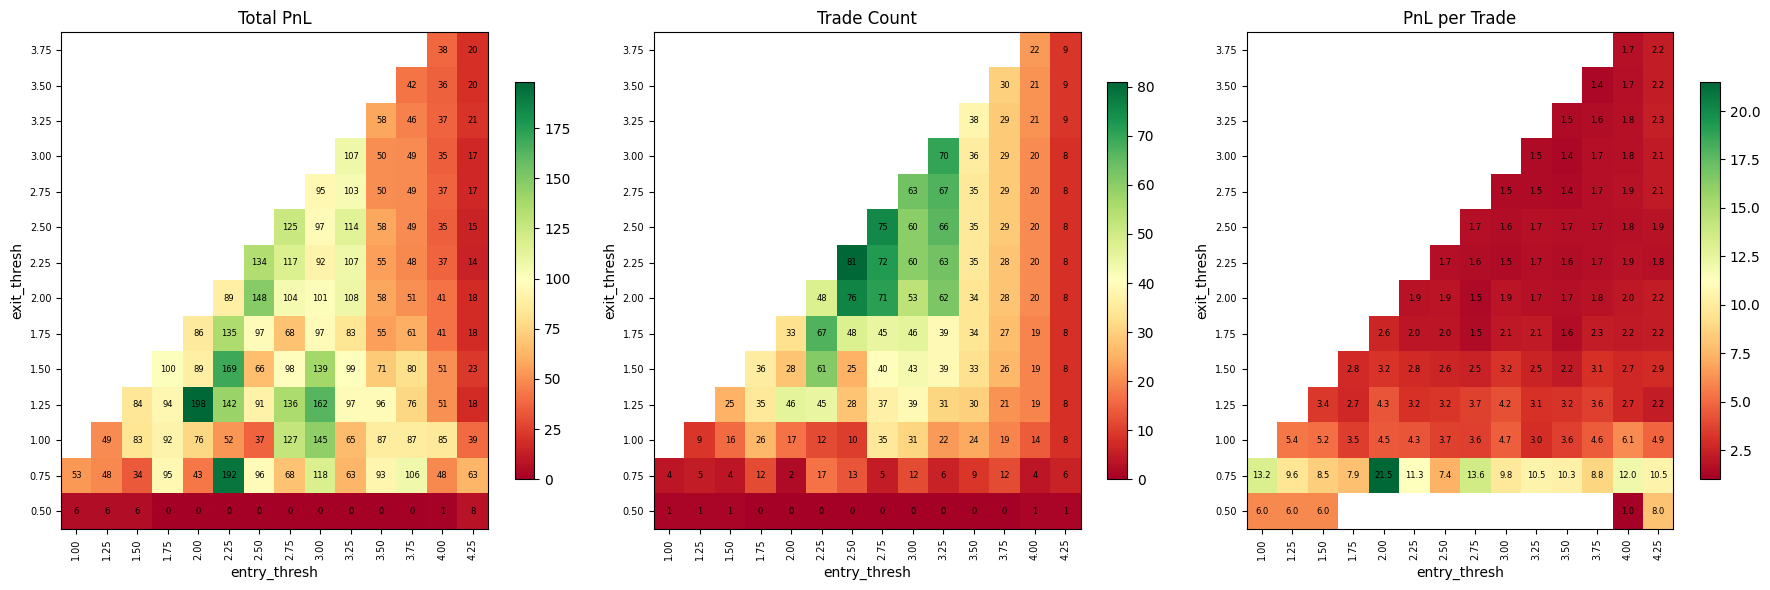

In [3]:
import matplotlib.pyplot as plt

data = load_velvetfruit()

entry_thresholds = np.round(np.arange(1.0, 4.5, 0.25), 2)
exit_thresholds  = np.round(np.arange(0.5, 4.0, 0.25), 2)

results = []
for et, xt in itertools.product(entry_thresholds, exit_thresholds):
    if xt >= et:
        continue
    pnl, trades = simulate(data, et, xt)
    results.append((et, xt, pnl, trades))

df = pd.DataFrame(results, columns=["entry", "exit", "pnl", "trades"])

pnl_grid   = df.pivot(index="exit", columns="entry", values="pnl").sort_index(ascending=False)
trade_grid = df.pivot(index="exit", columns="entry", values="trades").sort_index(ascending=False)
ppl_grid   = (df.assign(ppl=df["pnl"] / df["trades"].replace(0, np.nan))
                .pivot(index="exit", columns="entry", values="ppl")
                .sort_index(ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, grid, title, fmt in [
    (axes[0], pnl_grid,   "Total PnL",    ".0f"),
    (axes[1], trade_grid, "Trade Count",  ".0f"),
    (axes[2], ppl_grid,   "PnL per Trade",".1f"),
]:
    im = ax.imshow(grid.values, aspect="auto", cmap="RdYlGn")
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([f"{v:.2f}" for v in grid.columns], rotation=90, fontsize=7)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in grid.index], fontsize=7)
    ax.set_xlabel("entry_thresh")
    ax.set_ylabel("exit_thresh")
    ax.set_title(title)
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            v = grid.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, format(v, fmt), ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()

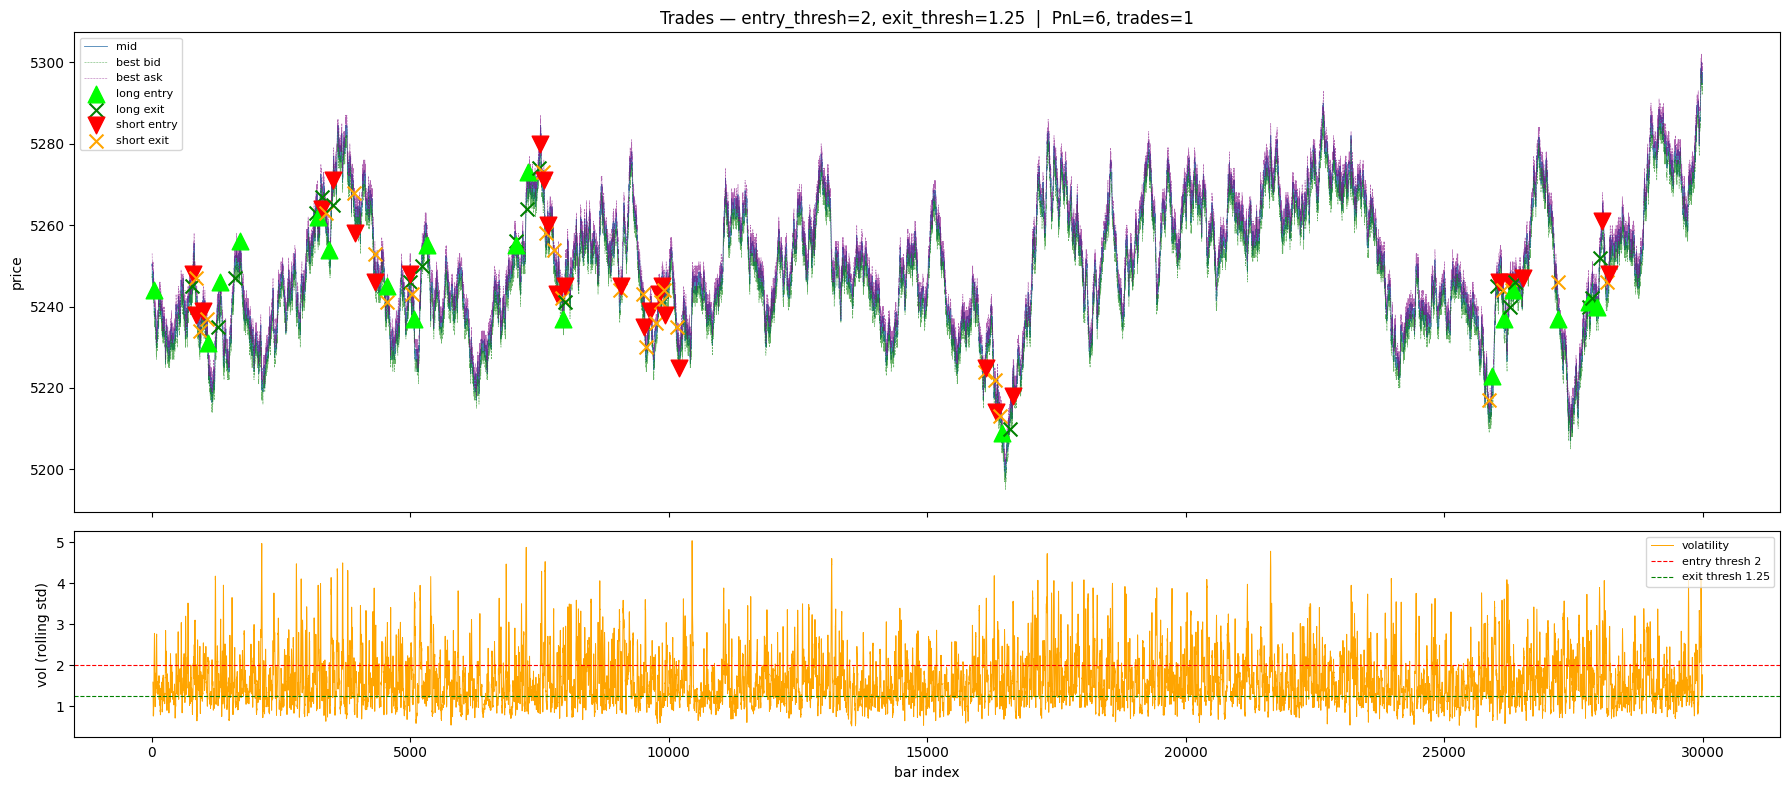

In [5]:
best = results[0]
best_et, best_xt = 2, 1.25
_, _, events = simulate(data, best_et, best_xt, record=True)

idx = np.arange(len(data))
mid_all = data["mid_price"].values
bid_all = data["bid_price_1"].values
ask_all = data["ask_price_1"].values
vol_all = pd.Series(mid_all).rolling(VOL_WIN).std().values

fig2, (ax_p, ax_v) = plt.subplots(2, 1, figsize=(18, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [7, 3]})

ax_p.plot(idx, mid_all, lw=0.6, color="steelblue", label="mid")
ax_p.plot(idx, bid_all, lw=0.4, color="green",    linestyle="--", alpha=0.6, label="best bid")
ax_p.plot(idx, ask_all, lw=0.4, color="purple",   linestyle="--", alpha=0.6, label="best ask")

markers = {
    "long_entry":  ("^", "lime",   12, "long entry"),
    "short_entry": ("v", "red",    12, "short entry"),
    "long_exit":   ("x", "green",  10, "long exit"),
    "short_exit":  ("x", "orange", 10, "short exit"),
}
plotted = set()
for i, price, kind in events:
    m, c, s, lbl = markers[kind]
    label = lbl if kind not in plotted else None
    ax_p.scatter(i, price, marker=m, color=c, s=s**2, zorder=5, label=label)
    plotted.add(kind)

ax_p.set_ylabel("price")
ax_p.set_title(f"Trades — entry_thresh={best_et}, exit_thresh={best_xt}  |  PnL={best[2]:.0f}, trades={best[3]}")
ax_p.legend(loc="upper left", fontsize=8)

ax_v.plot(idx, vol_all, lw=0.7, color="orange", label="volatility")
ax_v.axhline(best_et, color="red",   lw=0.8, linestyle="--", label=f"entry thresh {best_et}")
ax_v.axhline(best_xt, color="green", lw=0.8, linestyle="--", label=f"exit thresh {best_xt}")
ax_v.set_ylabel("vol (rolling std)")
ax_v.set_xlabel("bar index")
ax_v.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()